# Synchrony Contact Center Forecasting
## Datathon Project — Full Pipeline
**목표**: 4개 포트폴리오(A/B/C/D)의 콜센터 인바운드 콜 볼륨(CV), 고객응대시간(CCT), 포기율(ABD)을  
30분 간격으로 예측하는 모델 개발

**데이터**
- Daily: 2024.01 ~ 2025.12 (포트폴리오별)
- Interval: 2025년 4~6월 (30분 슬롯)
- Staffing: 2025년 전체 (포트폴리오별 일별 상담원 수)

**모델**
- Daily: LightGBM (train: ~2025.07 / test: 2025.08)
- Interval: LightGBM 직접 예측 (train: Apr+May / test: Jun)

## 0. 라이브러리 임포트

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

# 데이터 경로 (로컬에서 실행 시 수정)
DATA = '.'   # CSV 파일들이 있는 폴더
MONTH_MAP = {
    'January':1,'February':2,'March':3,'April':4,
    'May':5,'June':6,'July':7,'August':8,
    'September':9,'October':10,'November':11,'December':12
}
PORTFOLIOS = ['A', 'B', 'C', 'D']
COLORS = {'A':'#4C72B0','B':'#DD8452','C':'#55A868','D':'#C44E52'}

## 1. 데이터 로드 & 기본 전처리

### 1-1. Staffing 데이터

In [3]:
staffing_raw = pd.read_csv('Staffing.csv').rename(columns={'Unnamed: 0': 'Date'})
staffing_raw['Date'] = pd.to_datetime(staffing_raw['Date'])
print(f"Staffing shape: {staffing_raw.shape}")
print(f"Date range: {staffing_raw['Date'].min()} ~ {staffing_raw['Date'].max()}")
print(f"Missing values:\n{staffing_raw.isna().sum()}")
staffing_raw.head()

Staffing shape: (365, 5)
Date range: 2025-01-01 00:00:00 ~ 2025-12-31 00:00:00
Missing values:
Date     0
A       27
B       35
C       37
D       36
dtype: int64


,Date,A,B,C,D
0,2025-01-01,47.0,75.0,353.0,143.0
1,2025-01-02,82.0,184.0,491.0,195.0
2,2025-01-03,92.0,186.0,462.0,183.0
3,2025-01-04,70.0,148.0,352.0,155.0
4,2025-01-05,40.0,110.0,224.0,98.0


### 1-2. Daily 데이터 로드 함수

In [4]:
def load_daily(name, staffing):
    """
    Daily CSV 로드 + 타입 변환 + Staffing merge
    - Call Volume: 콤마 제거 후 numeric
    - Service Level / Abandon Rate: % 제거 후 numeric
    - staffing: 2025년만 존재 → 2024년은 NaN (이후 0으로 처리)
    """
    df_daily = pd.read_csv(f'{DATA}/{name}_Daily.csv')
    df_daily['Date'] = pd.to_datetime(df_daily['Date'].str[:8], format='%m/%d/%y')
    df_daily['Call Volume']  = pd.to_numeric(df_daily['Call Volume'].astype(str).str.replace(',', ''), errors='coerce')
    df_daily['Service Level']= pd.to_numeric(df_daily['Service Level'].astype(str).str.replace('%', ''), errors='coerce')
    df_daily['Abandon Rate'] = pd.to_numeric(df_daily['Abandon Rate'].astype(str).str.replace('%', ''), errors='coerce')
    df_daily['CCT']          = pd.to_numeric(df_daily['CCT'], errors='coerce')
    df_daily['portfolio']    = name
    df_daily = df_daily.sort_values('Date').reset_index(drop=True)
    df_daily = df_daily.merge(
        staffing[['Date', name]].rename(columns={name: 'staffing'}),
        on='Date', how='left'
    )
    return df_daily

daily = {n: load_daily(n, staffing_raw) for n in PORTFOLIOS}

for n in PORTFOLIOS:
    df_daily = daily[n]
    print(f"Portfolio {n}: {df_daily.shape} | "
          f"Date: {df_daily['Date'].min().date()} ~ {df_daily['Date'].max().date()} | "
          f"staffing null: {df_daily['staffing'].isna().sum()}")

Portfolio A: (731, 7) | Date: 2024-01-01 ~ 2025-12-31 | staffing null: 393
Portfolio B: (731, 7) | Date: 2024-01-01 ~ 2025-12-31 | staffing null: 401
Portfolio C: (731, 7) | Date: 2024-01-01 ~ 2025-12-31 | staffing null: 403
Portfolio D: (731, 7) | Date: 2024-01-01 ~ 2025-12-31 | staffing null: 402


In [5]:
df_daily.columns

Index(['Date', 'Call Volume', 'CCT', 'Service Level', 'Abandon Rate',
       'portfolio', 'staffing'],
      dtype='object')

### 1-3. Interval 데이터 로드 함수

In [6]:
def load_interval(name):
    """
    Interval CSV 로드 + 타입 변환
    - Interval 컬럼('HH:MM') → hour, minute, time_bin(0~47)
    - Month(문자) → month_num(숫자)
    - 포괄 데이터: 2025년 4~6월 (Apr/May/Jun)
    """
    df_interval = pd.read_csv(f'{DATA}/{name}_Interval.csv')
    df_interval['month_num']      = df_interval['Month'].map(MONTH_MAP)
    df_interval['Call Volume']    = pd.to_numeric(df_interval['Call Volume'], errors='coerce')
    df_interval['Abandoned Calls']= pd.to_numeric(df_interval['Abandoned Calls'], errors='coerce')
    df_interval['Service Level']  = pd.to_numeric(df_interval['Service Level'].astype(str).str.replace('%', ''), errors='coerce')
    df_interval['Abandoned Rate'] = pd.to_numeric(df_interval['Abandoned Rate'].astype(str).str.replace('%', ''), errors='coerce')
    df_interval['CCT']            = pd.to_numeric(df_interval['CCT'], errors='coerce')

    split = df_interval['Interval'].str.split(':', expand=True)
    df_interval['hour']   = pd.to_numeric(split[0], errors='coerce')
    df_interval['minute'] = pd.to_numeric(split[1], errors='coerce')
    df_interval = df_interval.dropna(subset=['hour', 'minute']).copy()
    df_interval['hour']    = df_interval['hour'].astype(int)
    df_interval['minute']  = df_interval['minute'].astype(int)
    df_interval['time_bin']= df_interval['hour'] * 2 + df_interval['minute'] // 30
    df_interval['portfolio']= name
    df_interval = df_interval.sort_values(['month_num', 'Day', 'time_bin']).reset_index(drop=True)
    return df_interval

interv = {n: load_interval(n) for n in PORTFOLIOS}

for n in PORTFOLIOS:
    df_interval = interv[n]
    print(f"Portfolio {n}: {df_interval.shape} | "
          f"Months: {sorted(df_interval['Month'].unique())} | "
          f"Rows/month: {df_interval.groupby('month_num').size().to_dict()}")

Portfolio A: (4076, 13) | Months: ['April', 'June', 'May'] | Rows/month: {4: 1329, 5: 1394, 6: 1353}
Portfolio B: (4285, 13) | Months: ['April', 'June', 'May'] | Rows/month: {4: 1416, 5: 1454, 6: 1415}
Portfolio C: (4359, 13) | Months: ['April', 'June', 'May'] | Rows/month: {4: 1431, 5: 1488, 6: 1440}
Portfolio D: (4358, 13) | Months: ['April', 'June', 'May'] | Rows/month: {4: 1438, 5: 1485, 6: 1435}


In [7]:
df_interval.columns

Index(['Month', 'Day', 'Interval', 'Service Level', 'Call Volume',
       'Abandoned Calls', 'Abandoned Rate', 'CCT', 'month_num', 'hour',
       'minute', 'time_bin', 'portfolio'],
      dtype='object')

## 2. 탐색적 데이터 분석 (EDA)

### 2-1. 포트폴리오별 Call Volume 규모 비교

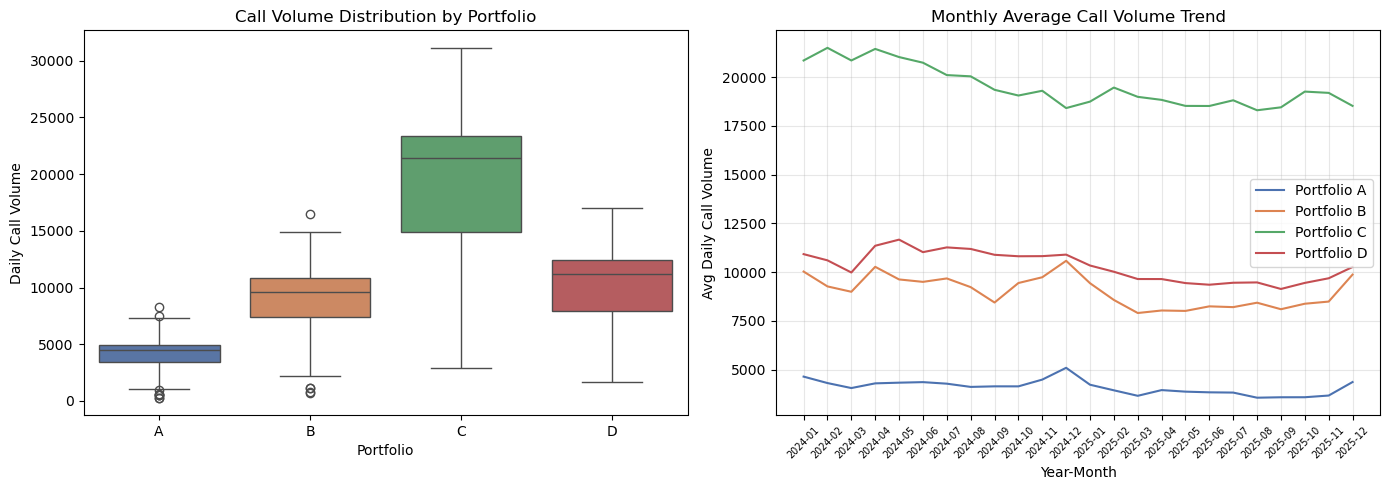


=== Daily CV 기초 통계 ===
Portfolio A: mean=4105, std=1414, min=290, max=8302
Portfolio B: mean=9041, std=2580, min=716, max=16467
Portfolio C: mean=19515, std=5597, min=2950, max=31121
Portfolio D: mean=10325, std=3015, min=1667, max=16967


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 박스플롯 - 포트폴리오별 CV 분포
combined_daily = pd.concat([
    daily[n][['Date', 'Call Volume', 'CCT', 'Abandon Rate']].assign(portfolio=n)
    for n in PORTFOLIOS
]).reset_index(drop= True)
sns.boxplot(x='portfolio', y='Call Volume', data=combined_daily, ax=axes[0],
            palette=[COLORS[n] for n in sorted(combined_daily['portfolio'].unique())])
axes[0].set_title('Call Volume Distribution by Portfolio', fontsize=12)
axes[0].set_xlabel('Portfolio')
axes[0].set_ylabel('Daily Call Volume')

# 월별 평균 CV 추이
for n in PORTFOLIOS:
    df = daily[n].copy()
    df['ym'] = df['Date'].dt.to_period('M')
    monthly = df.groupby('ym')['Call Volume'].mean()
    axes[1].plot(monthly.index.astype(str), monthly.values,
                 label=f'Portfolio {n}', color=COLORS[n], linewidth=1.5)
axes[1].set_title('Monthly Average Call Volume Trend', fontsize=12)
axes[1].set_xlabel('Year-Month')
axes[1].set_ylabel('Avg Daily Call Volume')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45, labelsize=7)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 기초 통계
print("\n=== Daily CV 기초 통계 ===")
for n in PORTFOLIOS:
    cv = daily[n]['Call Volume']
    print(f"Portfolio {n}: mean={cv.mean():.0f}, std={cv.std():.0f}, "
          f"min={cv.min():.0f}, max={cv.max():.0f}")

### 2-2. 요일별 패턴 분석

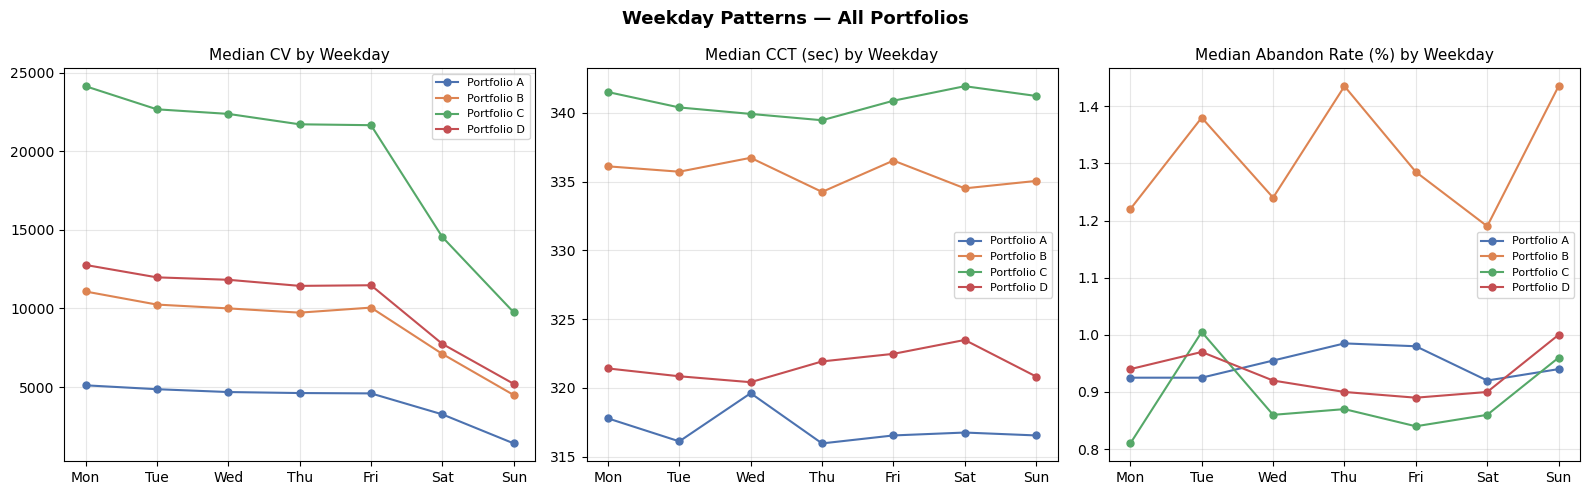

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
weekday_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

targets = [('Call Volume', 'CV'), ('CCT', 'CCT (sec)'), ('Abandon Rate', 'Abandon Rate (%)')]

for col, (tcol, tlabel) in enumerate(targets):
    ax = axes[col]
    for n in PORTFOLIOS:
        df = daily[n].copy()
        df['weekday'] = df['Date'].dt.dayofweek
        temp = df.groupby('weekday')[tcol].median()
        ax.plot(temp.index, temp.values, marker='o', label=f'Portfolio {n}',
                color=COLORS[n], linewidth=1.5, markersize=5)
    ax.set_title(f'Median {tlabel} by Weekday', fontsize=11)
    ax.set_xticks(range(7))
    ax.set_xticklabels(weekday_labels)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Weekday Patterns — All Portfolios', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 2-3. 시간대별 Interval 패턴 (Portfolio A 기준)

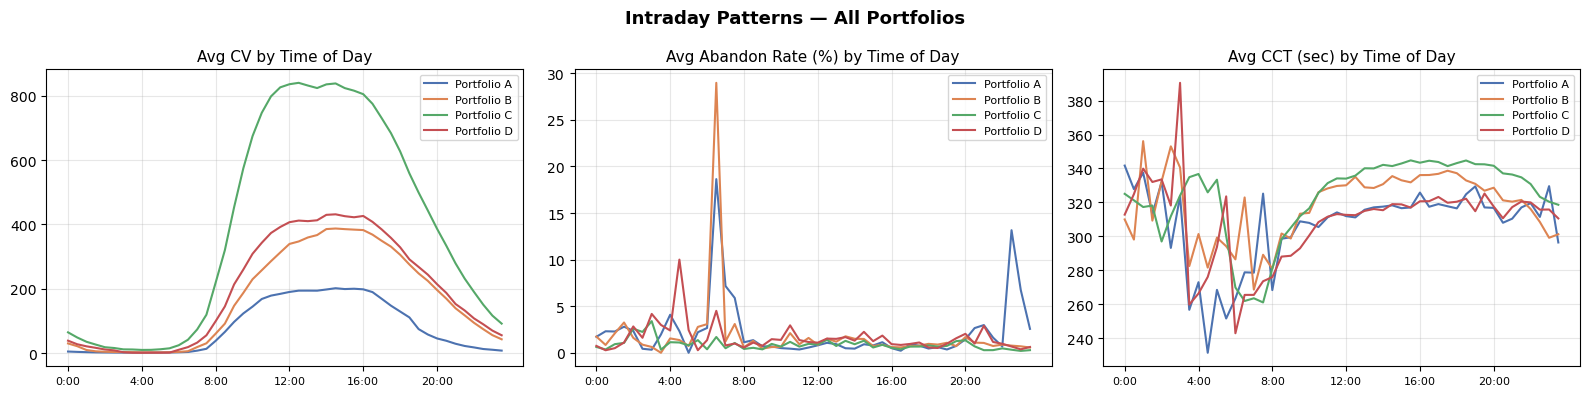

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
int_targets = [('Call Volume','CV'), ('Abandoned Rate','Abandon Rate (%)'), ('CCT','CCT (sec)')]

for col, (tcol, tlabel) in enumerate(int_targets):
    ax = axes[col]
    for n in PORTFOLIOS:
        df = interv[n].copy()
        temp = df.groupby('time_bin')[tcol].mean()
        ax.plot(temp.index, temp.values, label=f'Portfolio {n}',
                color=COLORS[n], linewidth=1.5)
    ticks = range(0, 48, 8)
    ax.set_xticks(list(ticks))
    ax.set_xticklabels([f'{i//2}:00' for i in ticks], fontsize=8)
    ax.set_title(f'Avg {tlabel} by Time of Day', fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Intraday Patterns — All Portfolios', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 2-4. 2024 vs 2025 연도별 비교 (Portfolio A)

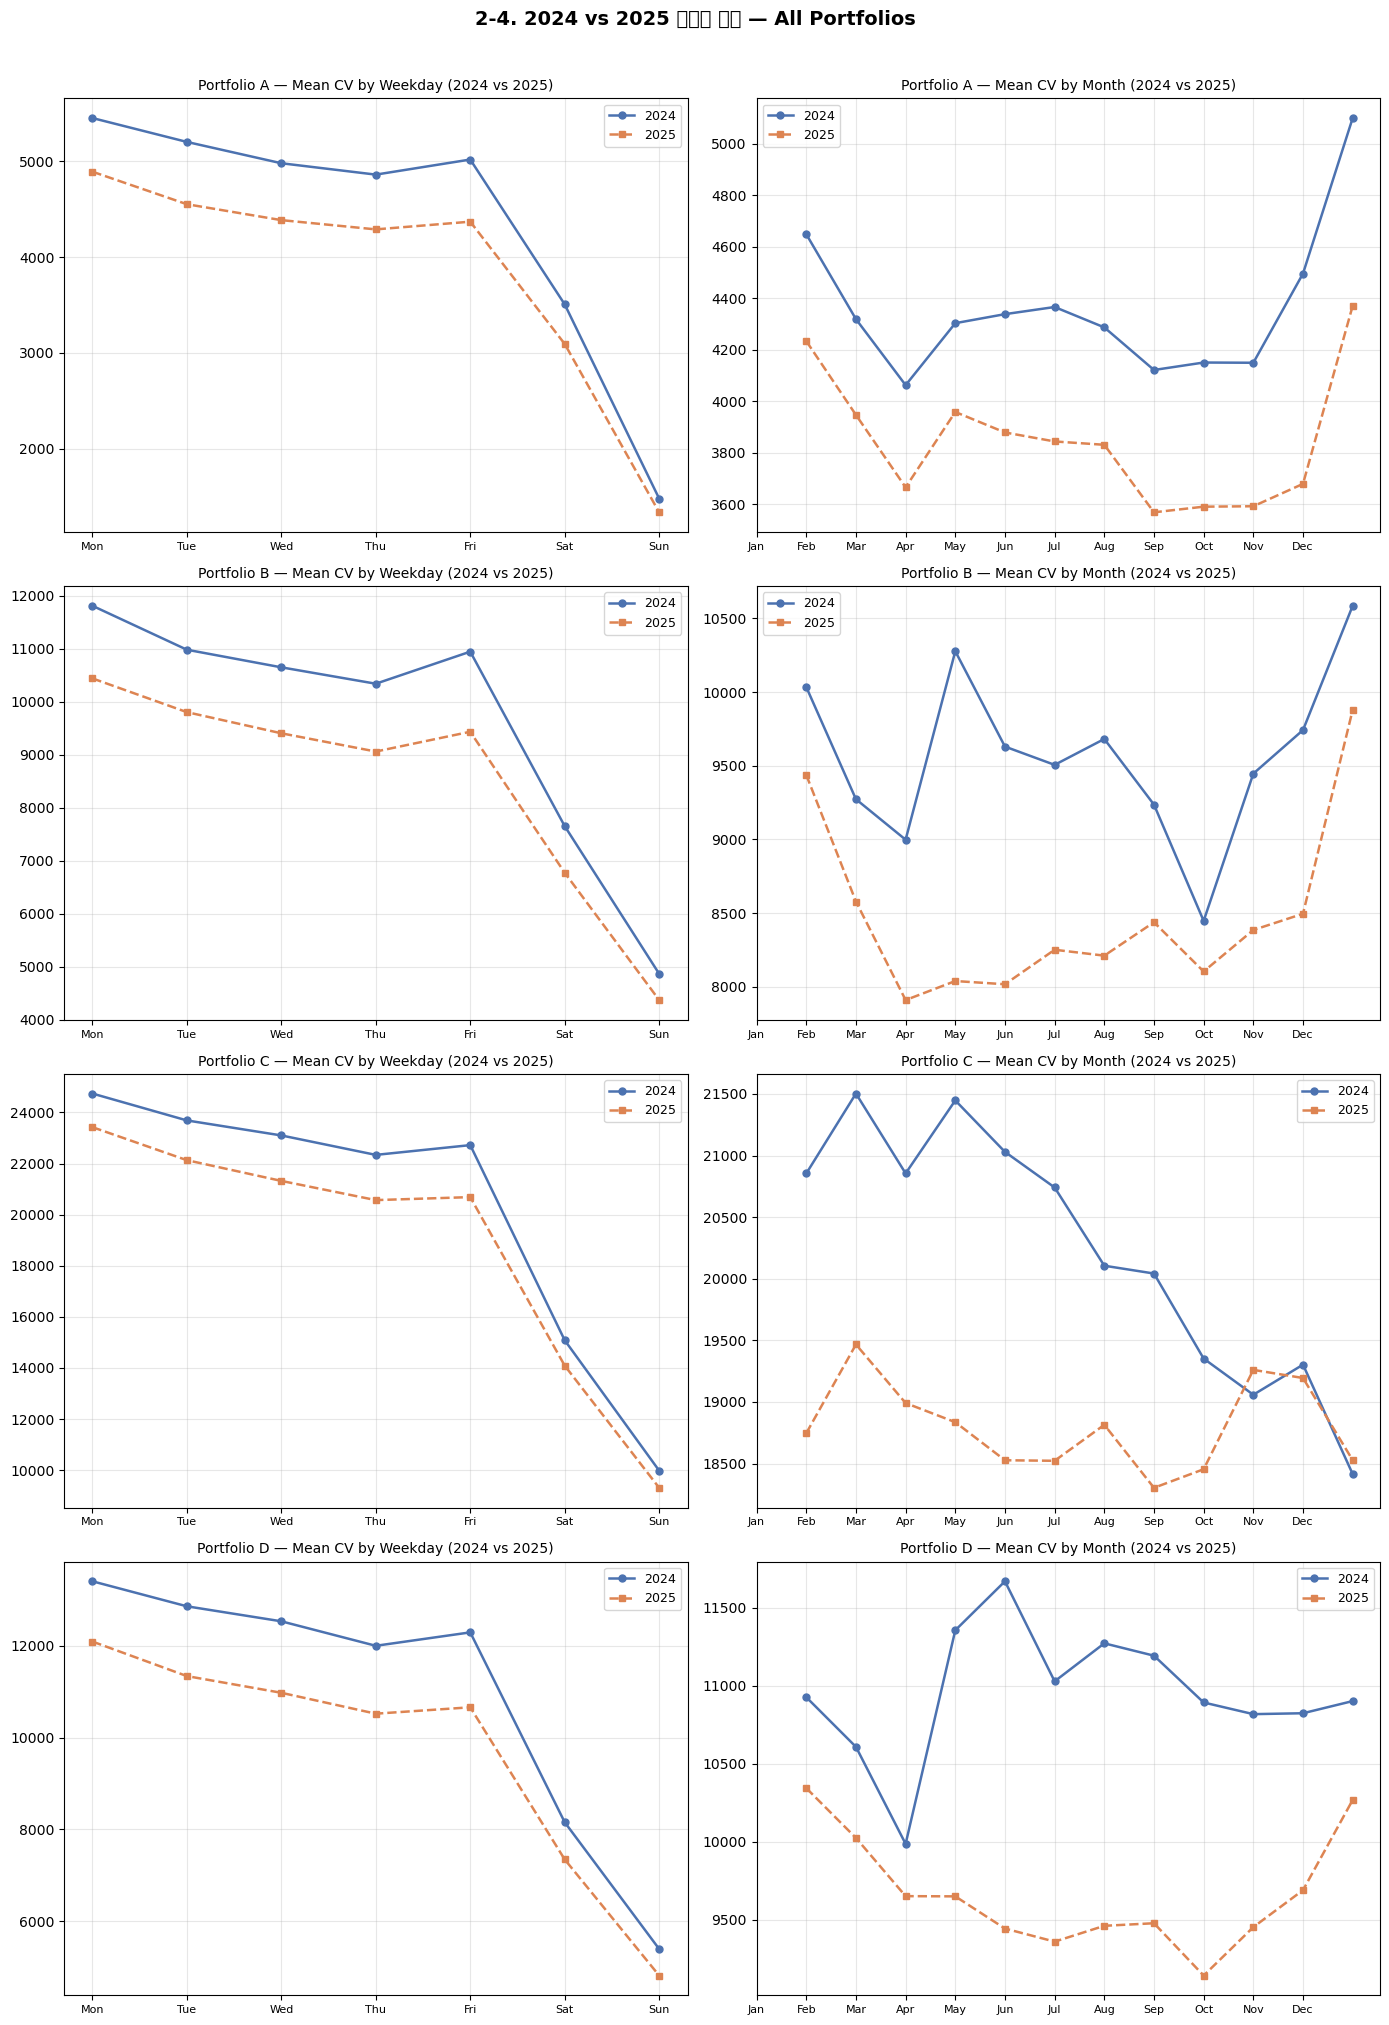

In [11]:
fig, axes = plt.subplots(4, 2, figsize=(14, 20))
fig.suptitle('2-4. 2024 vs 2025 연도별 비교 — All Portfolios', fontsize=14, fontweight='bold', y=1.01)

for row, name in enumerate(PORTFOLIOS):
    df = daily[name].copy()
    df['year']    = df['Date'].dt.year
    df['weekday'] = df['Date'].dt.dayofweek
    df['month']   = df['Date'].dt.month

    for ax, groupby_col, labels, title_suffix in zip(
        [axes[row][0], axes[row][1]],
        ['weekday', 'month'],
        [['Mon','Tue','Wed','Thu','Fri','Sat','Sun'],
         ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']],
        ['Weekday', 'Month']
    ):
        for year, ls, color in zip([2024,2025],['-o','--s'],['#4C72B0','#DD8452']):
            temp = df[df['year']==year].groupby(groupby_col)['Call Volume'].mean()
            ax.plot(temp.index, temp.values, ls, label=str(year), color=color, linewidth=1.8, markersize=5)
        ax.set_title(f'Portfolio {name} — Mean CV by {title_suffix} (2024 vs 2025)', fontsize=10)
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels, fontsize=8)
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()                              

### 2-5. 상관관계 분석 (Portfolio A)

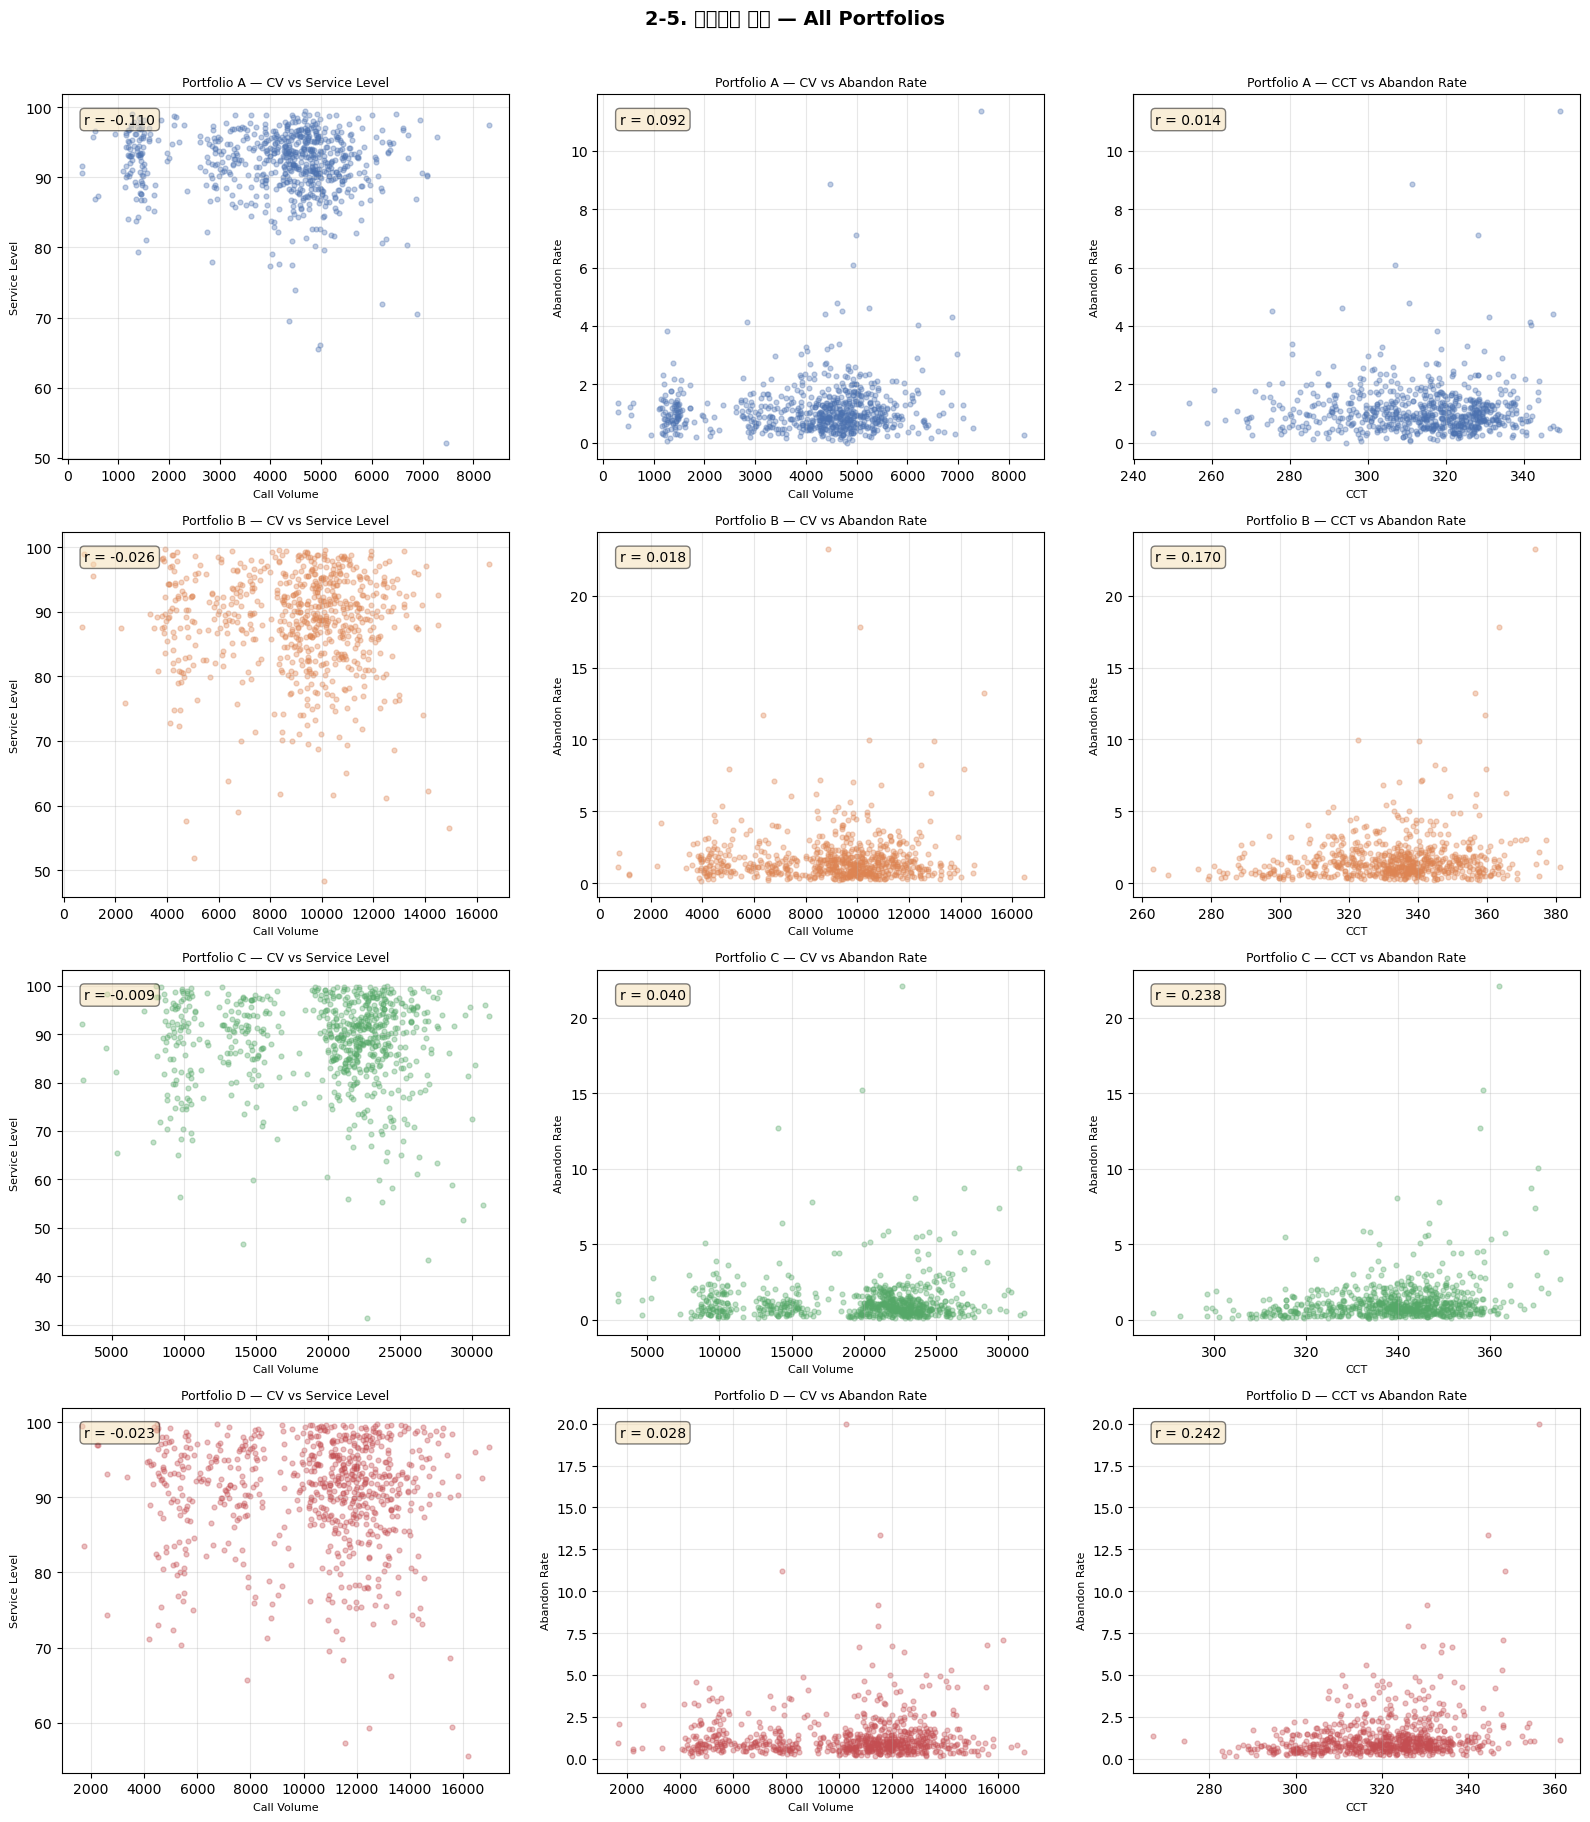

In [12]:
fig, axes = plt.subplots(4, 3, figsize=(16, 18))
fig.suptitle('2-5. 상관관계 분석 — All Portfolios', fontsize=14, fontweight='bold', y=1.01)

scatter_pairs = [
    ('Call Volume', 'Service Level', 'CV vs Service Level'),
    ('Call Volume', 'Abandon Rate',  'CV vs Abandon Rate'),
    ('CCT',         'Abandon Rate',  'CCT vs Abandon Rate'),
]

for row, name in enumerate(PORTFOLIOS):
    df = daily[name].copy()
    for col, (xcol, ycol, title) in enumerate(scatter_pairs):
        ax = axes[row][col]
        ax.scatter(df[xcol], df[ycol], alpha=0.35, s=12, color=COLORS[name])
        corr = df[[xcol, ycol]].corr().iloc[0, 1]
        ax.set_title(f'Portfolio {name} — {title}', fontsize=9)
        ax.set_xlabel(xcol, fontsize=8)
        ax.set_ylabel(ycol, fontsize=8)
        ax.text(0.05, 0.92, f'r = {corr:.3f}', transform=ax.transAxes,
                fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 2-6. Staffing 분석

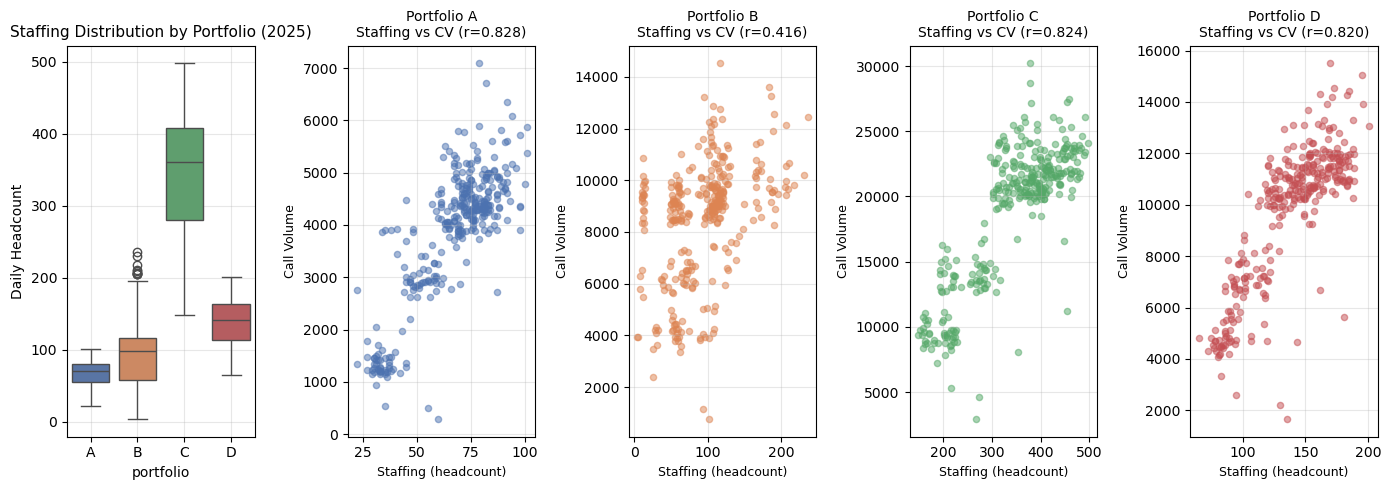

=== Staffing 기초 통계 (2025) ===
           A      B      C      D
count  338.0  330.0  328.0  329.0
mean    66.3   93.1  341.9  137.0
std     18.5   47.5   91.0   32.2
min     22.0    4.0  148.0   65.0
25%     55.0   58.0  280.2  114.0
50%     71.0   99.0  360.5  141.0
75%     80.0  116.0  408.0  163.0
max    101.0  236.0  498.0  201.0


In [13]:
fig, axes = plt.subplots(1, 5, figsize=(14, 5))

# 포트폴리오별 staffing 분포
staffing_plot = staffing_raw.melt(id_vars='Date', var_name='portfolio', value_name='staffing')
sns.boxplot(x='portfolio', y='staffing', data=staffing_plot, ax=axes[0],
            palette=COLORS)
axes[0].set_title('Staffing Distribution by Portfolio (2025)', fontsize=11)
axes[0].set_ylabel('Daily Headcount')
axes[0].grid(alpha = 0.3)

for col, name in enumerate(PORTFOLIOS):
    ax = axes[col + 1]
    df_2025 = daily[name].copy()
    df_2025 = df_2025[df_2025['Date'].dt.year == 2025].dropna(subset=['staffing'])
    ax.scatter(df_2025['staffing'], df_2025['Call Volume'],
               alpha=0.5, s=20, color=COLORS[name])
    corr = df_2025[['staffing', 'Call Volume']].corr().iloc[0, 1]
    ax.set_title(f'Portfolio {name}\nStaffing vs CV (r={corr:.3f})', fontsize=10)
    ax.set_xlabel('Staffing (headcount)', fontsize=9)
    ax.set_ylabel('Call Volume', fontsize=9)
    ax.grid(alpha=0.3)


plt.tight_layout()
plt.show()

print("=== Staffing 기초 통계 (2025) ===")
print(staffing_raw[['A','B','C','D']].describe().round(1))

## 3. 피처 엔지니어링

### 3-1. Daily 피처 엔지니어링

**설계 원칙**
- Lag 피처: 1일·7일·14일·28일 전 실제값 (과거 관성 포착)
- Rolling 피처: 직전 7일·14일 평균/표준편차 (단기 추세)
- Cyclic encoding: 요일·월·연중일을 sin/cos 쌍으로 변환 (원형 연속성)
- 공휴일 플래그: 미국 주요 공휴일·연말연시 명시적 처리
- Staffing 피처: 당일·전일·7일 rolling
- **결측치는 train 통계로만 채움** (데이터 누수 방지)

In [14]:
def make_daily_features(df, train_stats=None):
    """
    Daily 데이터 피처 엔지니어링.
    train_stats: None이면 train 단계(통계 계산), dict이면 test 단계(통계 적용)
    """
    df = df.copy()

    # 날짜 기반 피처
    df['year']        = df['Date'].dt.year
    df['month']       = df['Date'].dt.month
    df['day']         = df['Date'].dt.day
    df['weekday']     = df['Date'].dt.dayofweek
    df['weekofyear']  = df['Date'].dt.isocalendar().week.astype(int)
    df['is_weekend']  = (df['weekday'] >= 5).astype(int)
    df['quarter']     = df['Date'].dt.quarter
    df['day_of_year'] = df['Date'].dt.dayofyear

    # Cyclic encoding (원형 시간 표현)
    df['weekday_sin'] = np.sin(2 * np.pi * df['weekday'] / 7)
    df['weekday_cos'] = np.cos(2 * np.pi * df['weekday'] / 7)
    df['month_sin']   = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos']   = np.cos(2 * np.pi * df['month'] / 12)
    df['doy_sin']     = np.sin(2 * np.pi * df['day_of_year'] / 365)
    df['doy_cos']     = np.cos(2 * np.pi * df['day_of_year'] / 365)

    # 공휴일·특수일 플래그 (미국 기준)
    holidays = {(1,1),(7,4),(12,25),(12,24),(11,11),(1,15),(2,19),(5,27),(9,2),(11,28),(11,29)}
    df['is_holiday'] = df.apply(lambda r: int((r['month'], r['day']) in holidays), axis=1)
    df['is_yearend'] = ((df['month'] == 12) & (df['day'] >= 26)).astype(int)
    df['is_newyear'] = ((df['month'] == 1)  & (df['day'] <= 5)).astype(int)

    # Lag 피처 (1·7·14·28일 전)
    df = df.sort_values('Date').reset_index(drop=True)
    for lag in [1, 7, 14, 28]:
        df[f'lag_cv_{lag}']  = df['Call Volume'].shift(lag)
        df[f'lag_cct_{lag}'] = df['CCT'].shift(lag)
        df[f'lag_abd_{lag}'] = df['Abandon Rate'].shift(lag)

    # Rolling 통계 (shift(1): 당일값 제외)
    for w in [7, 14]:
        df[f'roll_cv_mean_{w}']  = df['Call Volume'].shift(1).rolling(w).mean()
        df[f'roll_cv_std_{w}']   = df['Call Volume'].shift(1).rolling(w).std()
        df[f'roll_abd_mean_{w}'] = df['Abandon Rate'].shift(1).rolling(w).mean()
        df[f'roll_cct_mean_{w}'] = df['CCT'].shift(1).rolling(w).mean()

    # Staffing 파생 피처
    df['staffing_lag1']  = df['staffing'].shift(1)
    df['staffing_roll7'] = df['staffing'].shift(1).rolling(7).mean()

    # 결측치 처리 (train 통계 기반, 누수 방지)
    if train_stats is None:
        stats = {}
        for c in ['Call Volume', 'CCT', 'Abandon Rate']:
            stats[c + '_median'] = df[c].median()
        train_stats = stats

    for c in ['Call Volume', 'CCT', 'Abandon Rate']:
        df[c] = df[c].fillna(train_stats[c + '_median'])
    df['staffing']       = df['staffing'].fillna(0)       # 2024년분 = 0
    df['staffing_lag1']  = df['staffing_lag1'].fillna(0)
    df['staffing_roll7'] = df['staffing_roll7'].fillna(0)

    for c in [col for col in df.columns if col.startswith(('lag_', 'roll_'))]:
        med = df[c].median()
        df[c] = df[c].fillna(med if not np.isnan(med) else 0)

    return df, train_stats

# 피처 목록
DAILY_FEATURES = [
    'year','month','day','weekday','weekofyear','is_weekend','quarter','day_of_year',
    'weekday_sin','weekday_cos','month_sin','month_cos','doy_sin','doy_cos',
    'is_holiday','is_yearend','is_newyear',
    'lag_cv_1','lag_cv_7','lag_cv_14','lag_cv_28',
    'lag_cct_1','lag_cct_7','lag_cct_14','lag_cct_28',
    'lag_abd_1','lag_abd_7','lag_abd_14','lag_abd_28',
    'roll_cv_mean_7','roll_cv_std_7','roll_cv_mean_14','roll_cv_std_14',
    'roll_abd_mean_7','roll_abd_mean_14',
    'roll_cct_mean_7','roll_cct_mean_14',
    'staffing','staffing_lag1','staffing_roll7'
]
print(f"Daily feature count: {len(DAILY_FEATURES)}")
print(DAILY_FEATURES)

Daily feature count: 40
['year', 'month', 'day', 'weekday', 'weekofyear', 'is_weekend', 'quarter', 'day_of_year', 'weekday_sin', 'weekday_cos', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos', 'is_holiday', 'is_yearend', 'is_newyear', 'lag_cv_1', 'lag_cv_7', 'lag_cv_14', 'lag_cv_28', 'lag_cct_1', 'lag_cct_7', 'lag_cct_14', 'lag_cct_28', 'lag_abd_1', 'lag_abd_7', 'lag_abd_14', 'lag_abd_28', 'roll_cv_mean_7', 'roll_cv_std_7', 'roll_cv_mean_14', 'roll_cv_std_14', 'roll_abd_mean_7', 'roll_abd_mean_14', 'roll_cct_mean_7', 'roll_cct_mean_14', 'staffing', 'staffing_lag1', 'staffing_roll7']


### 3-2. Interval 피처 엔지니어링

In [15]:
def make_interval_features(df, train_stats=None):
    """
    Interval 데이터 피처 엔지니어링.
    핵심: lag_cv_48 (24시간 전 동일 슬롯), time_bin (시간대 위치)
    """
    df = df.copy().sort_values(['month_num', 'Day', 'time_bin']).reset_index(drop=True)

    # 시간대 cyclic encoding
    df['hour_sin']     = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos']     = np.cos(2 * np.pi * df['hour'] / 24)
    df['month_sin']    = np.sin(2 * np.pi * df['month_num'] / 12)
    df['month_cos']    = np.cos(2 * np.pi * df['month_num'] / 12)
    df['timebin_sin']  = np.sin(2 * np.pi * df['time_bin'] / 48)
    df['timebin_cos']  = np.cos(2 * np.pi * df['time_bin'] / 48)

    # 날짜 복원 (2025년 Apr~Jun 기준)
    df['date_approx'] = pd.to_datetime(
        '2025-' + df['month_num'].astype(str).str.zfill(2)
        + '-' + df['Day'].astype(str).str.zfill(2), errors='coerce'
    )
    df['weekday']     = df['date_approx'].dt.dayofweek
    df['is_weekend']  = (df['weekday'] >= 5).astype(int)
    df['weekday_sin'] = np.sin(2 * np.pi * df['weekday'] / 7)
    df['weekday_cos'] = np.cos(2 * np.pi * df['weekday'] / 7)

    # 업무시간 플래그
    df['is_business_hour'] = ((df['hour'] >= 8)  & (df['hour'] < 20)).astype(int)
    df['is_peak']          = ((df['hour'] >= 10) & (df['hour'] < 14)).astype(int)
    df['is_morning_rush']  = ((df['hour'] >= 8)  & (df['hour'] < 11)).astype(int)
    df['is_evening_rush']  = ((df['hour'] >= 17) & (df['hour'] < 20)).astype(int)

    # Lag 피처 (48슬롯=24시간, 336슬롯=7일)
    df['lag_cv_48']  = df['Call Volume'].shift(48)
    df['lag_cv_336'] = df['Call Volume'].shift(48 * 7)
    df['lag_abd_48'] = df['Abandoned Rate'].shift(48)
    df['lag_cct_48'] = df['CCT'].shift(48)

    # Rolling (직전 2시간·4시간)
    df['roll_cv_2h']  = df['Call Volume'].shift(1).rolling(4,  min_periods=1).mean()
    df['roll_cv_4h']  = df['Call Volume'].shift(1).rolling(8,  min_periods=1).mean()
    df['roll_abd_2h'] = df['Abandoned Rate'].shift(1).rolling(4, min_periods=1).mean()

    # 결측치 처리
    if train_stats is None:
        stats = {c + '_median': df[c].median()
                 for c in ['Call Volume', 'CCT', 'Abandoned Rate']}
        train_stats = stats

    df['Call Volume']    = df['Call Volume'].fillna(train_stats['Call Volume_median'])
    df['CCT']            = df['CCT'].fillna(train_stats['CCT_median'])
    df['Abandoned Rate'] = df['Abandoned Rate'].fillna(train_stats['Abandoned Rate_median'])

    for c in [col for col in df.columns if col.startswith(('lag_', 'roll_'))]:
        med = df[c].median()
        df[c] = df[c].fillna(med if not pd.isna(med) else 0)

    return df, train_stats

# 피처 목록
INT_FEATURES = [
    'hour','minute','time_bin',
    'hour_sin','hour_cos','month_sin','month_cos','timebin_sin','timebin_cos',
    'weekday','is_weekend','weekday_sin','weekday_cos',
    'is_business_hour','is_peak','is_morning_rush','is_evening_rush',
    'month_num','Day',
    'lag_cv_48','lag_cv_336','lag_abd_48','lag_cct_48',
    'roll_cv_2h','roll_cv_4h','roll_abd_2h'
]
print(f"Interval feature count: {len(INT_FEATURES)}")
print(INT_FEATURES)

Interval feature count: 26
['hour', 'minute', 'time_bin', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'timebin_sin', 'timebin_cos', 'weekday', 'is_weekend', 'weekday_sin', 'weekday_cos', 'is_business_hour', 'is_peak', 'is_morning_rush', 'is_evening_rush', 'month_num', 'Day', 'lag_cv_48', 'lag_cv_336', 'lag_abd_48', 'lag_cct_48', 'roll_cv_2h', 'roll_cv_4h', 'roll_abd_2h']


## 4. Daily 모델링 (LightGBM)

**설계**
- 모델: LightGBM Regressor (포트폴리오별 독립 학습)
- CV: log1p 변환 후 학습 → expm1으로 역변환 (양수 보장)
- Train: 2024.01 ~ 2025.07 | Test: 2025.08 (31일)
- Early stopping: val RMSE 기준 50 rounds
- 음수 클리핑: `np.maximum(pred, 0)`

In [16]:
LGBM_PARAMS = dict(
    n_estimators=800,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=6,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    verbose=-1,
    n_jobs=-1
)

daily_results = {}
daily_models  = {}
train_stats_all = {}

print("=" * 60)
print("Daily Model Training Results")
print("=" * 60)

for name in PORTFOLIOS:
    df_feat, stats = make_daily_features(daily[name].copy())
    train_stats_all[name] = stats

    train = df_feat[df_feat['Date'] < '2025-08-01'].dropna(subset=DAILY_FEATURES)
    test  = df_feat[(df_feat['Date'] >= '2025-08-01') & (df_feat['Date'] < '2025-09-01')]

    targets = {'CV': 'Call Volume', 'CCT': 'CCT', 'ABD': 'Abandon Rate'}
    result  = {'Date': test['Date'].values}
    models  = {}

    print(f"\n── Portfolio {name}  (train: {len(train)}, test: {len(test)}) ──")

    for tkey, tcol in targets.items():
        y_tr = train[tcol]
        y_te = test[tcol]
        y_tr_fit = np.log1p(y_tr) if tkey == 'CV' else y_tr

        model = lgb.LGBMRegressor(**LGBM_PARAMS)
        model.fit(
            train[DAILY_FEATURES], y_tr_fit,
            eval_set=[(test[DAILY_FEATURES], np.log1p(y_te) if tkey == 'CV' else y_te)],
            callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=-1)]
        )
        models[tkey] = model

        pred = model.predict(test[DAILY_FEATURES])
        if tkey == 'CV':
            pred = np.expm1(pred)
        pred = np.maximum(pred, 0)

        result[tkey + '_pred'] = pred
        result[tkey + '_true'] = y_te.values

        rmse = root_mean_squared_error(y_te, pred)
        mae  = mean_absolute_error(y_te, pred)
        mask = y_te.values > 0.1
        mape = np.mean(np.abs((y_te.values[mask] - pred[mask]) / y_te.values[mask])) * 100
        trees = model.best_iteration_ if model.best_iteration_ else 800
        print(f"  {tkey:4s} | RMSE: {rmse:8.2f} | MAE: {mae:8.2f} | MAPE: {mape:5.1f}% | trees: {trees}")

    daily_results[name] = pd.DataFrame(result)
    daily_models[name]  = models

Daily Model Training Results

── Portfolio A  (train: 578, test: 31) ──
  CV   | RMSE:   255.84 | MAE:   188.22 | MAPE:   5.9% | trees: 162
  CCT  | RMSE:    12.11 | MAE:    10.11 | MAPE:   3.2% | trees: 99
  ABD  | RMSE:     0.77 | MAE:     0.56 | MAPE:  35.2% | trees: 4

── Portfolio B  (train: 578, test: 31) ──
  CV   | RMSE:   767.82 | MAE:   552.48 | MAPE:   7.2% | trees: 197
  CCT  | RMSE:    11.05 | MAE:     8.63 | MAPE:   2.6% | trees: 61
  ABD  | RMSE:     1.51 | MAE:     1.12 | MAPE:  54.5% | trees: 48

── Portfolio C  (train: 578, test: 31) ──
  CV   | RMSE:  1069.72 | MAE:   713.25 | MAPE:   3.7% | trees: 150
  CCT  | RMSE:    10.88 | MAE:     7.84 | MAPE:   2.4% | trees: 51
  ABD  | RMSE:     1.32 | MAE:     0.87 | MAPE:  52.8% | trees: 102

── Portfolio D  (train: 578, test: 31) ──
  CV   | RMSE:  1186.57 | MAE:   813.58 | MAPE:   8.3% | trees: 56
  CCT  | RMSE:    13.79 | MAE:    11.31 | MAPE:   3.4% | trees: 159
  ABD  | RMSE:     1.18 | MAE:     0.85 | MAPE:  75.9% | t

### 4-1. Daily 예측 결과 시각화

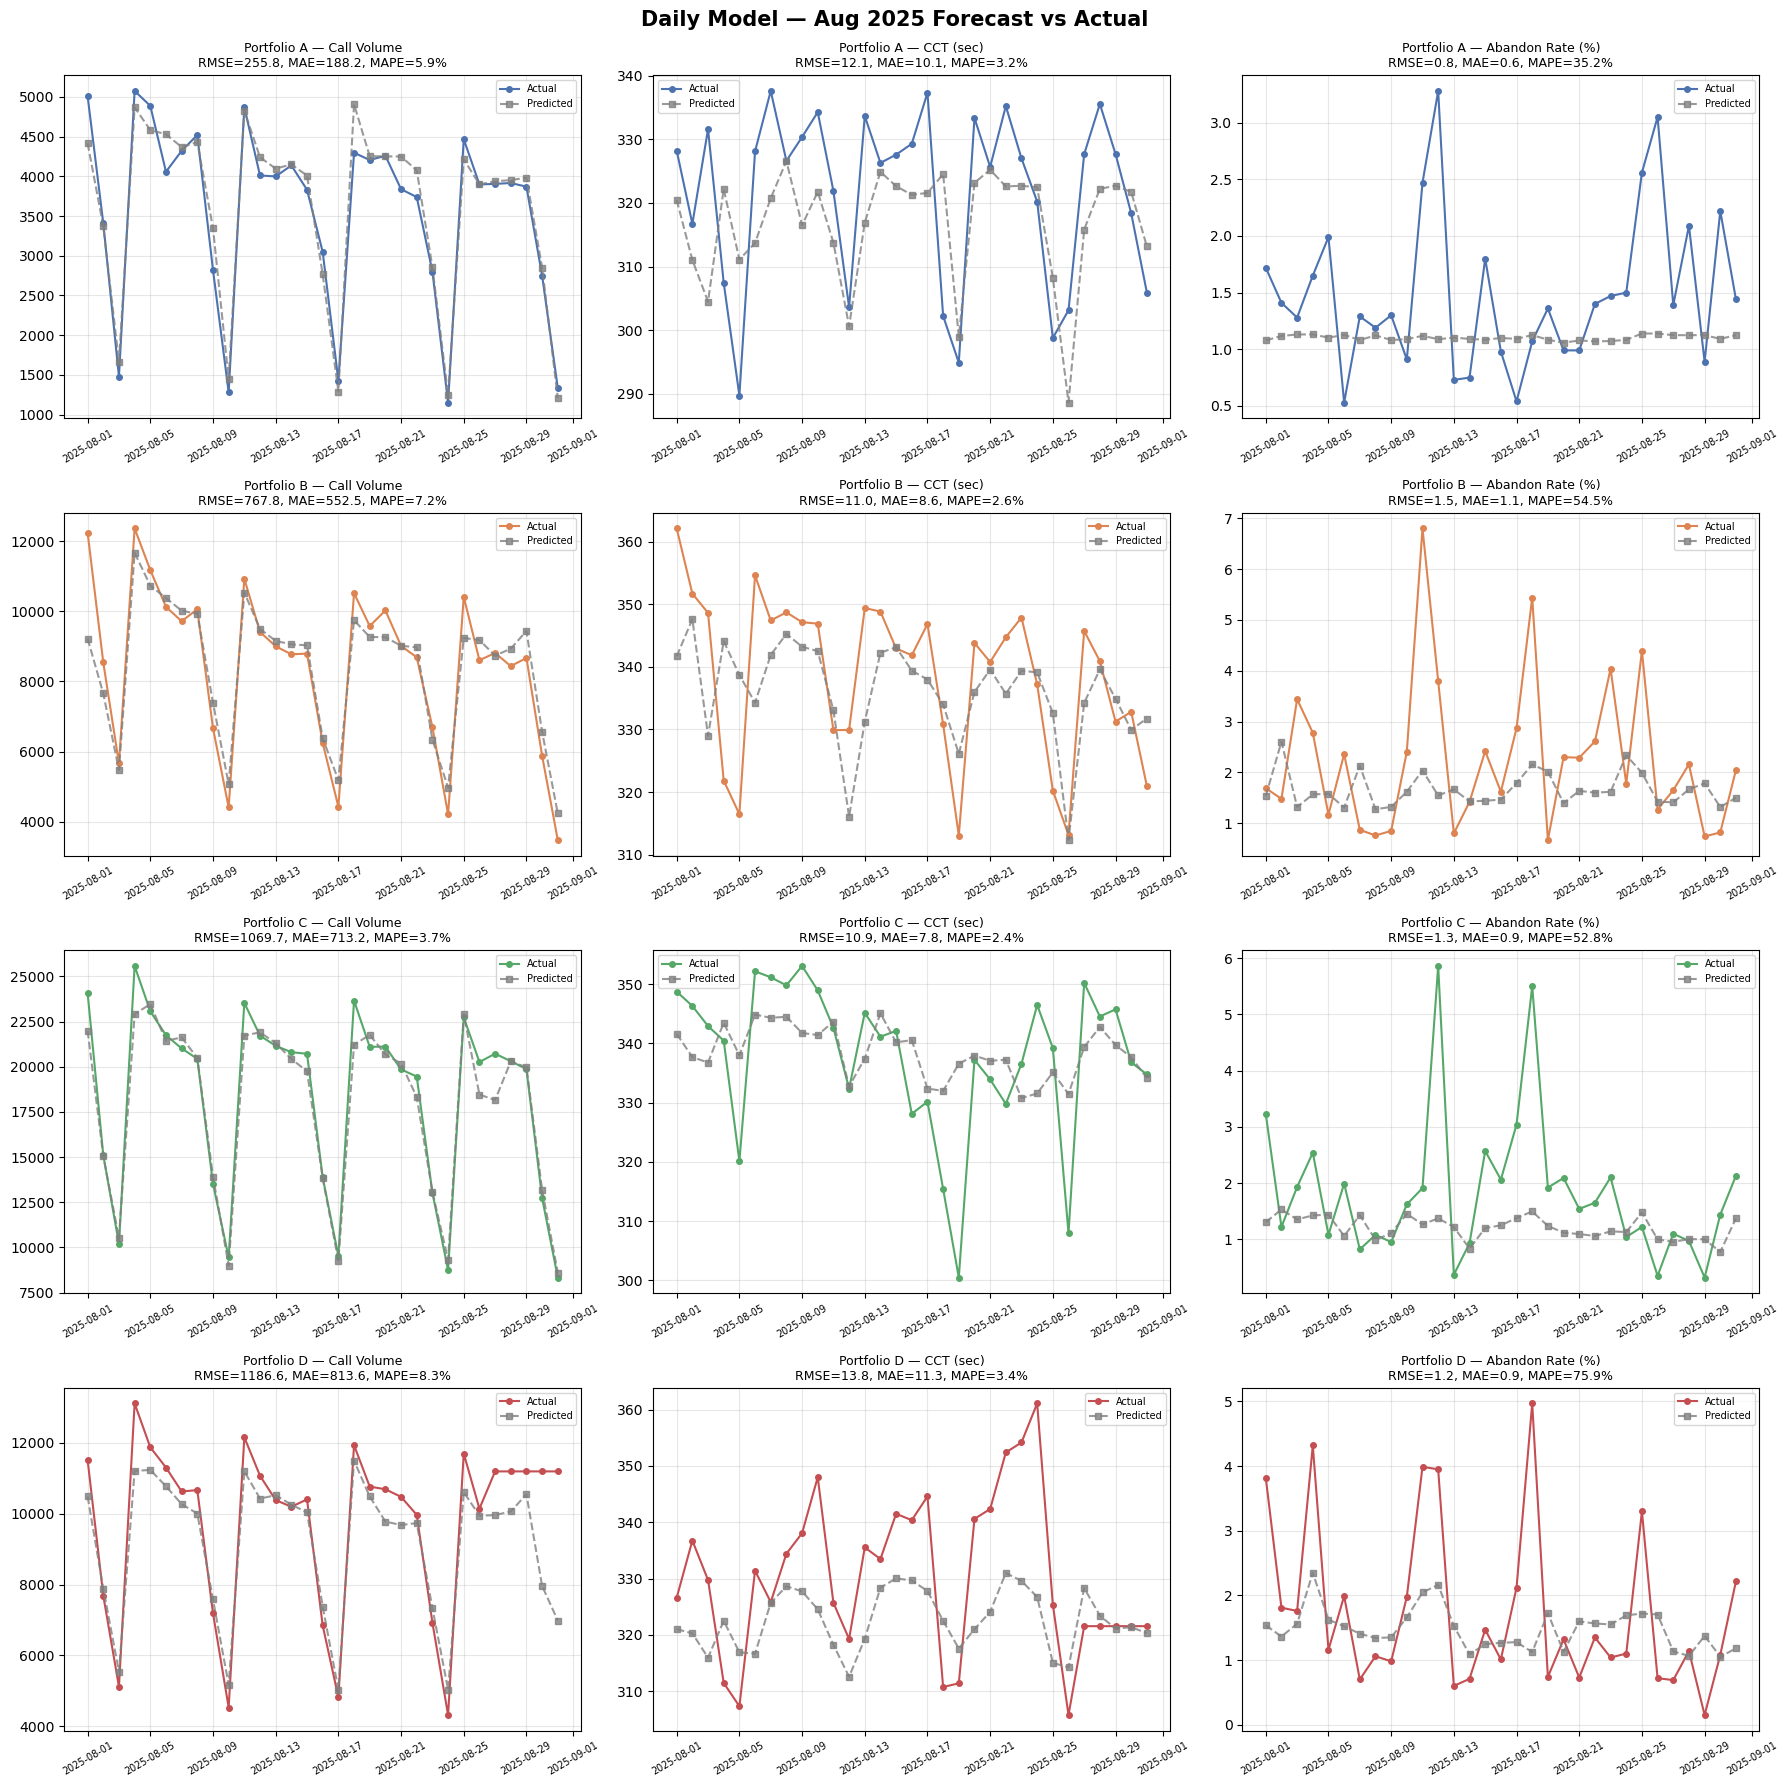

In [17]:
fig, axes = plt.subplots(4, 3, figsize=(18, 18))
fig.suptitle('Daily Model — Aug 2025 Forecast vs Actual', fontsize=15, fontweight='bold', y=0.99)
TARGETS_LABEL = {'CV': 'Call Volume', 'CCT': 'CCT (sec)', 'ABD': 'Abandon Rate (%)'}

for row, name in enumerate(PORTFOLIOS):
    res   = daily_results[name]
    dates = pd.to_datetime(res['Date'])
    for col, tkey in enumerate(['CV', 'CCT', 'ABD']):
        ax   = axes[row][col]
        true = res[tkey + '_true']
        pred = res[tkey + '_pred']
        ax.plot(dates, true, 'o-', color=COLORS[name], label='Actual',   linewidth=1.5, markersize=4)
        ax.plot(dates, pred, 's--', color='gray',      label='Predicted', linewidth=1.5, markersize=4, alpha=0.8)
        rmse = root_mean_squared_error(true, pred)
        mae  = mean_absolute_error(true, pred)
        mask = true > 0.1
        mape = np.mean(np.abs((true[mask] - pred[mask]) / true[mask])) * 100
        ax.set_title(f'Portfolio {name} — {TARGETS_LABEL[tkey]}\nRMSE={rmse:.1f}, MAE={mae:.1f}, MAPE={mape:.1f}%', fontsize=9)
        ax.tick_params(axis='x', rotation=30, labelsize=7)
        ax.legend(fontsize=7)
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Interval 모델링 (LightGBM 직접 예측)

**기존 코드와의 핵심 차이**
- 기존: Daily 예측값을 과거 비율로 30분 단위로 분배 (Top-Down)
- 개선: LightGBM이 30분 슬롯을 직접 예측 (End-to-End)

**Train: Apr+May 2025 | Test: Jun 2025**

In [18]:
INT_LGBM = dict(
    n_estimators=600,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=7,
    min_child_samples=10,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.05,
    reg_lambda=0.1,
    random_state=42,
    verbose=-1,
    n_jobs=-1
)

interval_results = {}
interval_models  = {}

print("=" * 60)
print("Interval Model Training Results")
print("=" * 60)

for name in PORTFOLIOS:
    df_feat, _ = make_interval_features(interv[name].copy())

    train = df_feat[df_feat['month_num'] < 6].dropna(subset=INT_FEATURES)
    test  = df_feat[df_feat['month_num'] == 6]

    int_targets = {'CV': 'Call Volume', 'CCT': 'CCT', 'ABD': 'Abandoned Rate'}
    result = {
        'month': test['month_num'].values, 'Day': test['Day'].values,
        'hour': test['hour'].values, 'minute': test['minute'].values,
        'time_bin': test['time_bin'].values
    }
    models_int = {}

    print(f"\n── Portfolio {name}  (train: {len(train)}, test: {len(test)}) ──")

    for tkey, tcol in int_targets.items():
        y_tr = train[tcol]
        y_te = test[tcol]
        y_tr_fit = np.log1p(y_tr) if tkey == 'CV' else y_tr

        model = lgb.LGBMRegressor(**INT_LGBM)
        model.fit(
            train[INT_FEATURES], y_tr_fit,
            eval_set=[(test[INT_FEATURES], np.log1p(y_te) if tkey == 'CV' else y_te)],
            callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=-1)]
        )
        models_int[tkey] = model

        pred = model.predict(test[INT_FEATURES])
        if tkey == 'CV':
            pred = np.expm1(pred)
        pred = np.maximum(pred, 0)

        result[tkey + '_pred'] = pred
        result[tkey + '_true'] = y_te.values

        rmse = root_mean_squared_error(y_te, pred)
        mae  = mean_absolute_error(y_te, pred)
        mask = y_te.values > 0.5
        mape = np.mean(np.abs((y_te.values[mask] - pred[mask]) / y_te.values[mask])) * 100 if mask.sum() > 0 else float('nan')
        trees = model.best_iteration_ if model.best_iteration_ else 800
        print(f"  {tkey:4s} | RMSE: {rmse:8.2f} | MAE: {mae:8.2f} | MAPE: {mape:5.1f}% | trees: {trees}" )

    interval_results[name] = pd.DataFrame(result)
    interval_models[name]  = models_int

Interval Model Training Results

── Portfolio A  (train: 2723, test: 1353) ──
  CV   | RMSE:    18.82 | MAE:     9.76 | MAPE:  28.6% | trees: 78
  CCT  | RMSE:   100.46 | MAE:    58.39 | MAPE:  23.4% | trees: 2
  ABD  | RMSE:     7.34 | MAE:     2.77 | MAPE:  52.8% | trees: 39

── Portfolio B  (train: 2870, test: 1415) ──
  CV   | RMSE:    27.11 | MAE:    15.50 | MAPE:  22.0% | trees: 93
  CCT  | RMSE:    78.88 | MAE:    45.04 | MAPE:  18.8% | trees: 8
  ABD  | RMSE:     4.77 | MAE:     1.83 | MAPE:  52.4% | trees: 37

── Portfolio C  (train: 2919, test: 1440) ──
  CV   | RMSE:    56.55 | MAE:    26.60 | MAPE:  14.0% | trees: 89
  CCT  | RMSE:    51.94 | MAE:    28.13 | MAPE:   9.1% | trees: 44
  ABD  | RMSE:     2.23 | MAE:     1.15 | MAPE:  50.7% | trees: 9

── Portfolio D  (train: 2923, test: 1435) ──
  CV   | RMSE:    28.66 | MAE:    15.84 | MAPE:  17.0% | trees: 113
  CCT  | RMSE:    59.04 | MAE:    32.60 | MAPE:  13.8% | trees: 14
  ABD  | RMSE:     3.75 | MAE:     1.74 | MAPE:  

### 5-1. Interval 예측 결과 시각화 (June 1일 샘플)

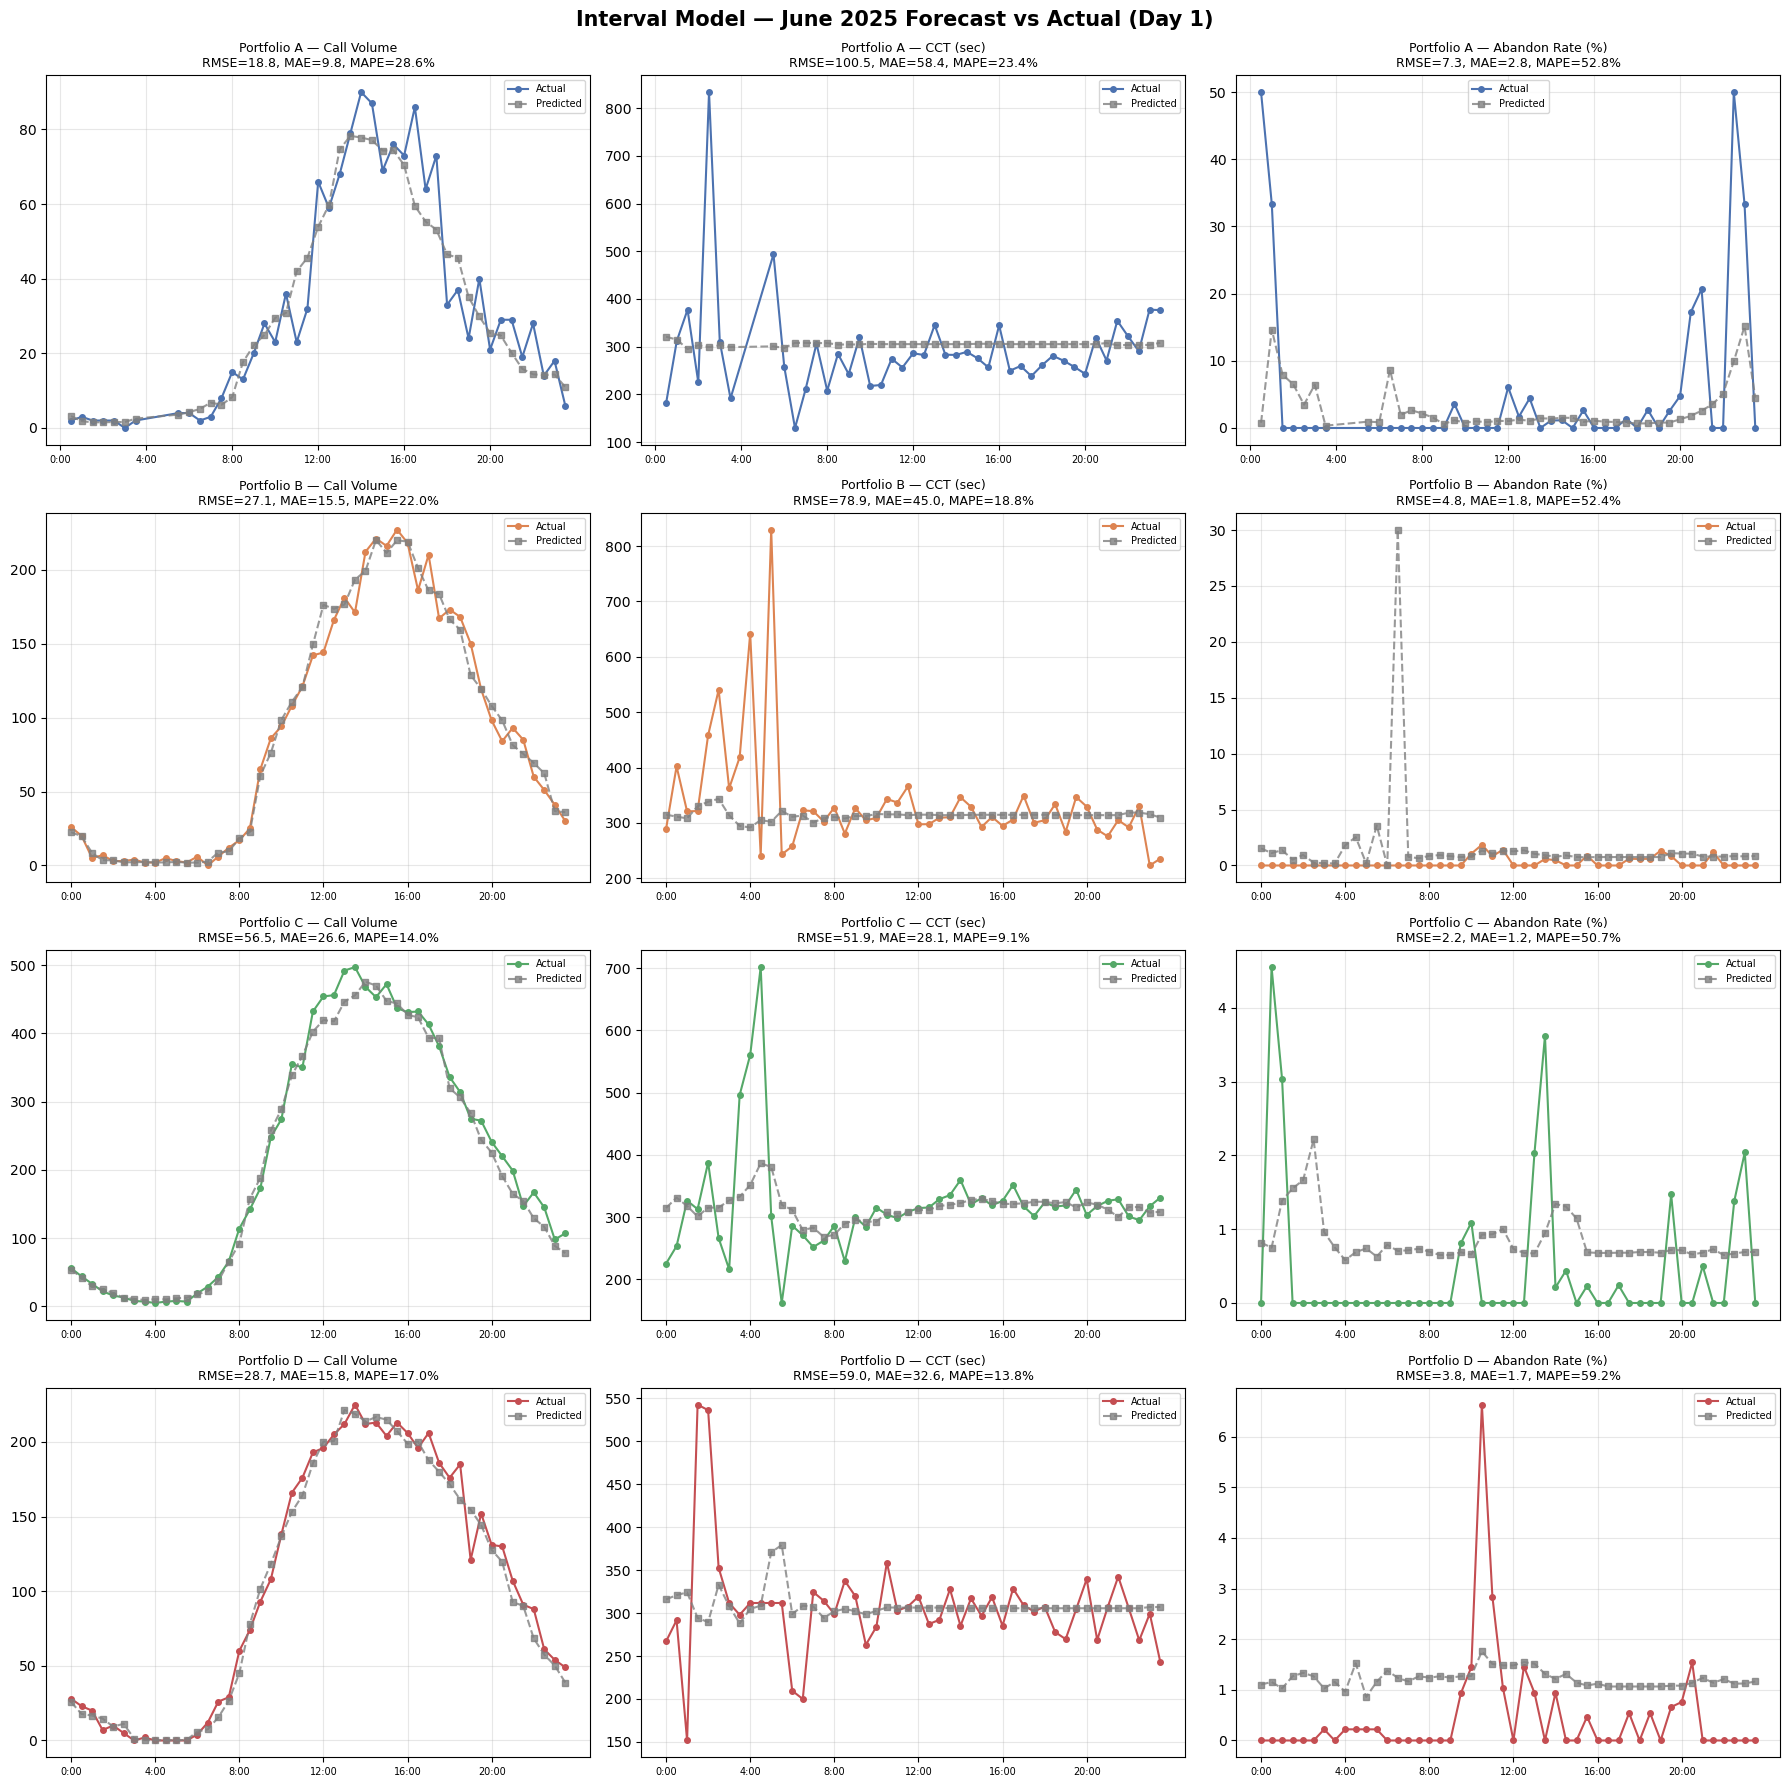

In [19]:
fig2, axes2 = plt.subplots(4, 3, figsize=(18, 18))
fig2.suptitle('Interval Model — June 2025 Forecast vs Actual (Day 1)', fontsize=15, fontweight='bold', y=0.99)

for row, name in enumerate(PORTFOLIOS):
    res  = interval_results[name]
    day1 = res[res['Day'] == 1].sort_values('time_bin')
    for col, tkey in enumerate(['CV', 'CCT', 'ABD']):
        ax   = axes2[row][col]
        true = day1[tkey + '_true'].values
        pred = day1[tkey + '_pred'].values
        bins = day1['time_bin'].values
        ax.plot(bins, true, 'o-',  color=COLORS[name], label='Actual',   linewidth=1.5, markersize=4)
        ax.plot(bins, pred, 's--', color='gray',       label='Predicted', linewidth=1.5, markersize=4, alpha=0.8)
        rmse_all = root_mean_squared_error(res[tkey+'_true'], res[tkey+'_pred'])
        mae_all  = mean_absolute_error(res[tkey+'_true'], res[tkey+'_pred'])
        all_true, all_pred = res[tkey+'_true'], res[tkey+'_pred']
        mask = all_true > 0.5
        mape = np.mean(np.abs((all_true[mask]-all_pred[mask])/all_true[mask]))*100 if mask.sum()>0 else float('nan')
        xticks = list(range(0, 48, 8))
        ax.set_xticks(xticks)
        ax.set_xticklabels([f'{i//2}:00' for i in xticks], fontsize=7)
        ax.set_title(f'Portfolio {name} — {TARGETS_LABEL[tkey]}\nRMSE={rmse_all:.1f}, MAE={mae_all:.1f}, MAPE={mape:.1f}%', fontsize=9)
        ax.legend(fontsize=7)
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Feature Importance

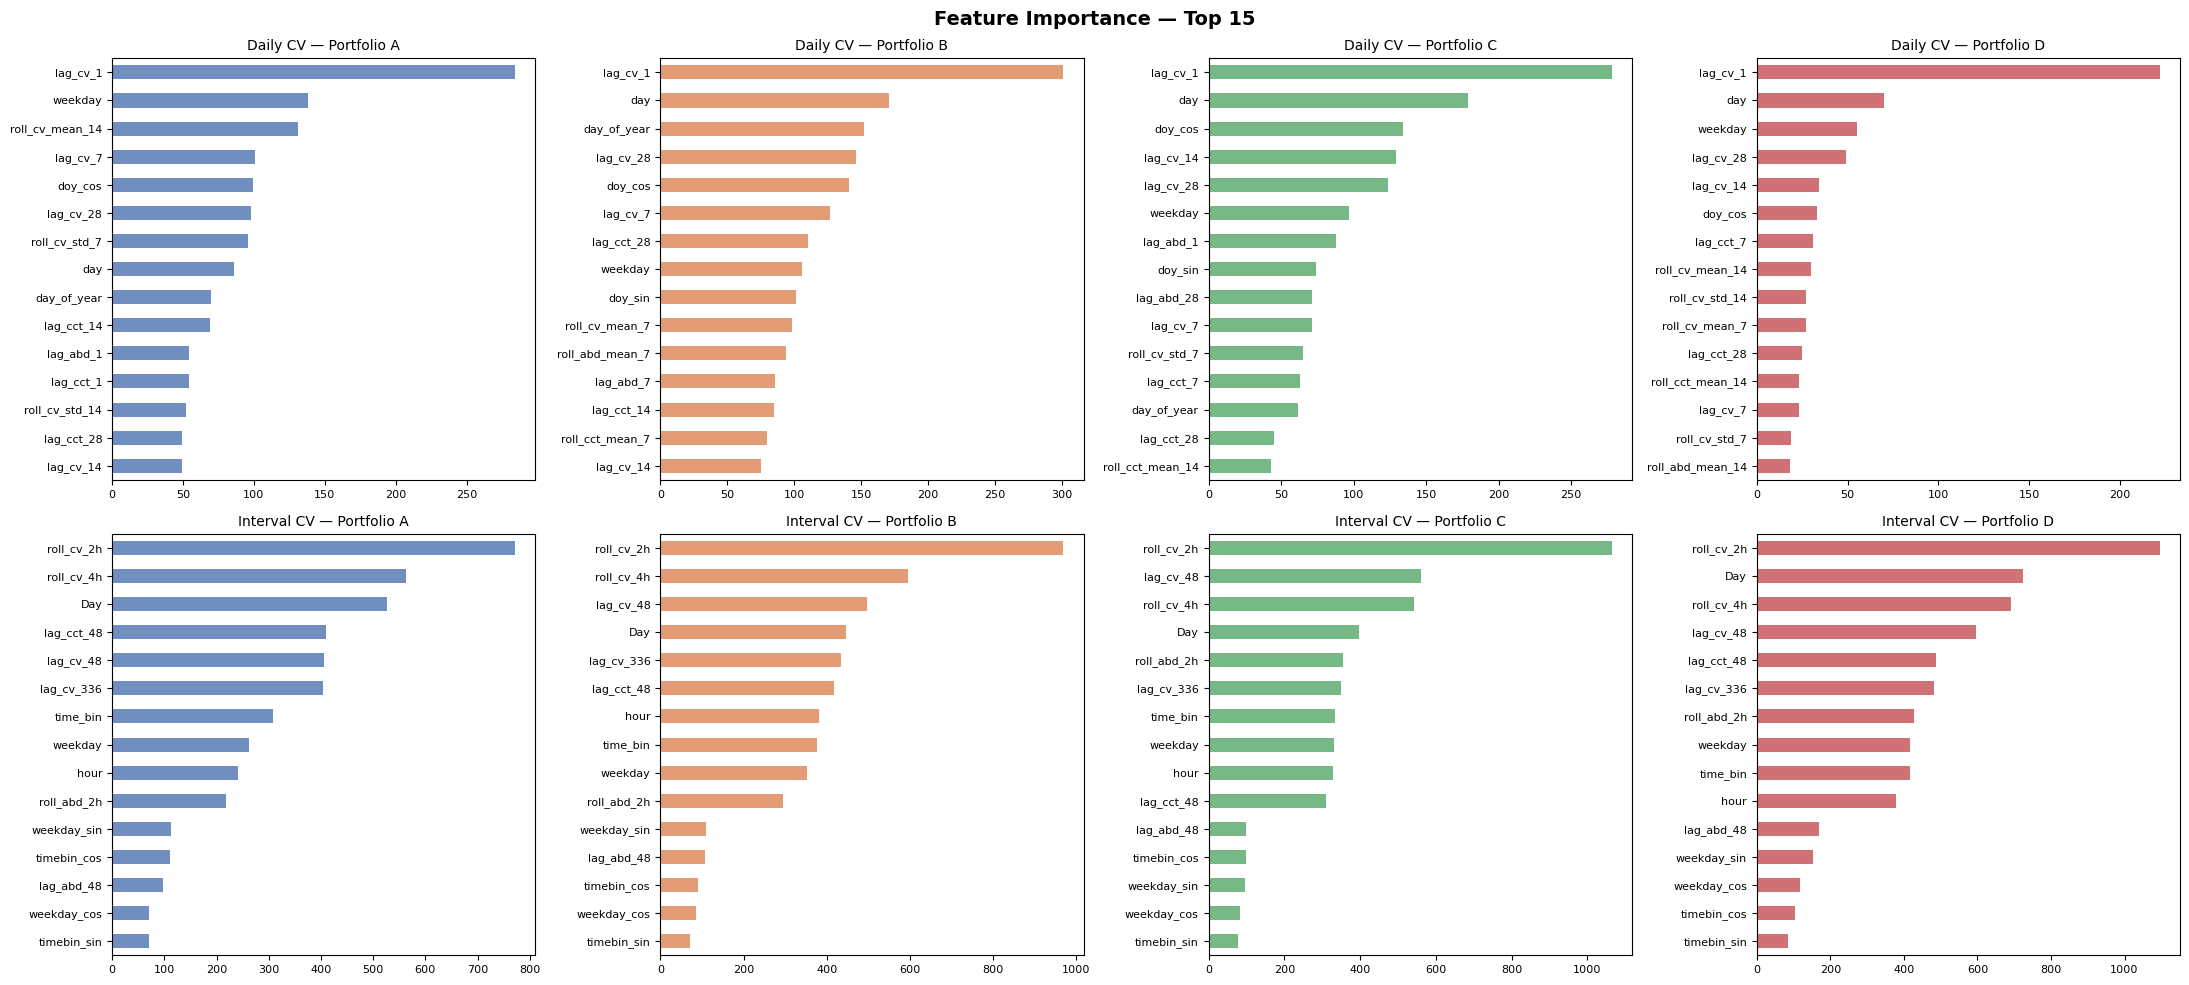

In [20]:
fig3, axes3 = plt.subplots(2, 4, figsize=(22, 10))
fig3.suptitle('Feature Importance — Top 15', fontsize=14, fontweight='bold')

for col, name in enumerate(PORTFOLIOS):
    # Daily CV
    ax = axes3[0][col]
    imp = pd.Series(daily_models[name]['CV'].feature_importances_, index=DAILY_FEATURES)
    imp.nlargest(15).sort_values().plot(kind='barh', ax=ax, color=COLORS[name], alpha=0.8)
    ax.set_title(f'Daily CV — Portfolio {name}', fontsize=10)
    ax.tick_params(labelsize=8)

    # Interval CV
    ax2 = axes3[1][col]
    imp2 = pd.Series(interval_models[name]['CV'].feature_importances_, index=INT_FEATURES)
    imp2.nlargest(15).sort_values().plot(kind='barh', ax=ax2, color=COLORS[name], alpha=0.8)
    ax2.set_title(f'Interval CV — Portfolio {name}', fontsize=10)
    ax2.tick_params(labelsize=8)

plt.tight_layout()
plt.show()

### 6-1. Staffing 피처 실제 순위 확인

In [21]:
print("=== Staffing Feature Importance Rank (Daily CV) ===")
print(f"{'Portfolio':>12} | {'staffing':>10} | {'staffing_lag1':>14} | {'staffing_roll7':>15} | {'Total features':>15}")
print("-" * 72)
for name in PORTFOLIOS:
    imp = pd.Series(daily_models[name]['CV'].feature_importances_, index=DAILY_FEATURES)
    ranks = imp.rank(ascending=False).astype(int)
    print(f"  {name:>10} | {ranks['staffing']:>10} | {ranks['staffing_lag1']:>14} | "
          f"{ranks['staffing_roll7']:>15} | {len(DAILY_FEATURES):>15}")
print()
print("Note: staffing 데이터가 2025년만 존재 → 2024년 구간 전체가 0으로 채워져 중요도 낮음")

=== Staffing Feature Importance Rank (Daily CV) ===
   Portfolio |   staffing |  staffing_lag1 |  staffing_roll7 |  Total features
------------------------------------------------------------------------
           A |         32 |             25 |              21 |              40
           B |         32 |             31 |              35 |              40
           C |         33 |             34 |              36 |              40
           D |         21 |             21 |              33 |              40

Note: staffing 데이터가 2025년만 존재 → 2024년 구간 전체가 0으로 채워져 중요도 낮음


## 7. 최종 성능 요약

In [24]:
print("=" * 95)
print("Final Performance Summary")
print("  Daily   : Train 2024.01~2025.07 / Test 2025.08 (31 days)")
print("  Interval: Train Apr+May 2025    / Test Jun 2025")
print("=" * 95)

# ── Daily ────────────────────────────────────────────────────────────
print(f"\n[Daily]")
print(f"  {'':12s} {'CV 평균':>8} {'CV RMSE':>9} {'CV MAPE':>9} {'CCT RMSE':>10} {'CCT MAPE':>10} {'ABD RMSE':>10} {'ABD MAPE':>10}")
print("  " + "-" * 90)

for name in PORTFOLIOS:
    r = daily_results[name]
    cv_mean  = r['CV_true'].mean()
    cv_rmse  = root_mean_squared_error(r['CV_true'],  r['CV_pred'])
    cct_rmse = root_mean_squared_error(r['CCT_true'], r['CCT_pred'])
    abd_rmse = root_mean_squared_error(r['ABD_true'], r['ABD_pred'])
    mask_cv  = r['CV_true']  > 0.1
    mask_cct = r['CCT_true'] > 0.1
    mask_abd = r['ABD_true'] > 0.1
    cv_mape  = np.mean(np.abs((r['CV_true'][mask_cv]   - r['CV_pred'][mask_cv])   / r['CV_true'][mask_cv]))   * 100
    cct_mape = np.mean(np.abs((r['CCT_true'][mask_cct] - r['CCT_pred'][mask_cct]) / r['CCT_true'][mask_cct])) * 100
    abd_mape = np.mean(np.abs((r['ABD_true'][mask_abd] - r['ABD_pred'][mask_abd]) / r['ABD_true'][mask_abd])) * 100
    print(f"  Portfolio {name} | {cv_mean:7.0f} | {cv_rmse:8.1f} | {cv_mape:8.1f}% | {cct_rmse:9.1f} | {cct_mape:9.1f}% | {abd_rmse:9.3f} | {abd_mape:9.1f}%")

# ── Interval 전체 슬롯 ────────────────────────────────────────────────
print(f"\n[Interval — 전체 슬롯]")
print(f"  {'':12s} {'CV 평균':>8} {'CV RMSE':>9} {'CV MAPE':>9} {'CCT RMSE':>10} {'CCT MAPE':>10} {'ABD RMSE':>10} {'ABD MAPE':>10}")
print("  " + "-" * 90)

for name in PORTFOLIOS:
    r = interval_results[name]
    cv_mean  = r['CV_true'].mean()
    cv_rmse  = root_mean_squared_error(r['CV_true'],  r['CV_pred'])
    cct_rmse = root_mean_squared_error(r['CCT_true'], r['CCT_pred'])
    abd_rmse = root_mean_squared_error(r['ABD_true'], r['ABD_pred'])
    mask_cv  = r['CV_true']  > 0.5
    mask_cct = r['CCT_true'] > 1
    mask_abd = r['ABD_true'] > 0.1
    cv_mape  = np.mean(np.abs((r['CV_true'][mask_cv]   - r['CV_pred'][mask_cv])   / r['CV_true'][mask_cv]))   * 100 if mask_cv.sum()  > 0 else float('nan')
    cct_mape = np.mean(np.abs((r['CCT_true'][mask_cct] - r['CCT_pred'][mask_cct]) / r['CCT_true'][mask_cct])) * 100 if mask_cct.sum() > 0 else float('nan')
    abd_mape = np.mean(np.abs((r['ABD_true'][mask_abd] - r['ABD_pred'][mask_abd]) / r['ABD_true'][mask_abd])) * 100 if mask_abd.sum() > 0 else float('nan')
    print(f"  Portfolio {name} | {cv_mean:7.1f} | {cv_rmse:8.1f} | {cv_mape:8.1f}% | {cct_rmse:9.1f} | {cct_mape:9.1f}% | {abd_rmse:9.3f} | {abd_mape:9.1f}%")

# ── Interval 업무시간(8시~20시)만 ─────────────────────────────────────
print(f"\n[Interval — 업무시간(8시~20시)만]")
print(f"  {'':12s} {'CV 업무평균':>10} {'CV RMSE':>9} {'CV/평균':>8} {'CV MAPE':>9} {'CCT RMSE':>10} {'CCT MAPE':>10} {'ABD RMSE':>10} {'ABD MAPE':>10}")
print("  " + "-" * 100)

for name in PORTFOLIOS:
    r = interval_results[name]
    if 'hour' in r.columns:
        biz = r[(r['hour'] >= 8) & (r['hour'] < 20)]
    else:
        biz = r[(r['time_bin'] >= 16) & (r['time_bin'] < 40)]

    cv_mean_biz  = biz['CV_true'].mean()
    cv_rmse_biz  = root_mean_squared_error(biz['CV_true'],  biz['CV_pred'])
    cct_rmse_biz = root_mean_squared_error(biz['CCT_true'], biz['CCT_pred'])
    abd_rmse_biz = root_mean_squared_error(biz['ABD_true'], biz['ABD_pred'])
    cv_ratio     = cv_rmse_biz / cv_mean_biz * 100   # CV/평균 비율

    mask_cv_biz  = biz['CV_true']  > 0.5
    mask_cct_biz = biz['CCT_true'] > 1
    mask_abd_biz = biz['ABD_true'] > 0.1
    cv_mape_biz  = np.mean(np.abs((biz['CV_true'][mask_cv_biz]   - biz['CV_pred'][mask_cv_biz])   / biz['CV_true'][mask_cv_biz]))   * 100 if mask_cv_biz.sum()  > 0 else float('nan')
    cct_mape_biz = np.mean(np.abs((biz['CCT_true'][mask_cct_biz] - biz['CCT_pred'][mask_cct_biz]) / biz['CCT_true'][mask_cct_biz])) * 100 if mask_cct_biz.sum() > 0 else float('nan')
    abd_mape_biz = np.mean(np.abs((biz['ABD_true'][mask_abd_biz] - biz['ABD_pred'][mask_abd_biz]) / biz['ABD_true'][mask_abd_biz])) * 100 if mask_abd_biz.sum() > 0 else float('nan')

    print(f"  Portfolio {name} | {cv_mean_biz:9.1f} | {cv_rmse_biz:8.1f} | {cv_ratio:7.1f}% | {cv_mape_biz:8.1f}% | {cct_rmse_biz:9.1f} | {cct_mape_biz:9.1f}% | {abd_rmse_biz:9.3f} | {abd_mape_biz:9.1f}%")

print()
print("  ※ CV/평균: RMSE ÷ 업무시간 평균 CV × 100 (포트폴리오 간 상대적 오차 비교용)")
print("  ※ ABD MAPE가 높은 것은 실제값이 0~2%로 작아 분모 문제 발생 → RMSE로 해석 권장")

Final Performance Summary
  Daily   : Train 2024.01~2025.07 / Test 2025.08 (31 days)
  Interval: Train Apr+May 2025    / Test Jun 2025

[Daily]
                  CV 평균   CV RMSE   CV MAPE   CCT RMSE   CCT MAPE   ABD RMSE   ABD MAPE
  ------------------------------------------------------------------------------------------
  Portfolio A |    3568 |    255.8 |      5.9% |      12.1 |       3.2% |     0.771 |      35.2%
  Portfolio B |    8438 |    767.8 |      7.2% |      11.0 |       2.6% |     1.509 |      54.5%
  Portfolio C |   18303 |   1069.7 |      3.7% |      10.9 |       2.4% |     1.323 |      52.8%
  Portfolio D |    9754 |   1186.6 |      8.3% |      13.8 |       3.4% |     1.176 |      75.9%

[Interval — 전체 슬롯]
                  CV 평균   CV RMSE   CV MAPE   CCT RMSE   CCT MAPE   ABD RMSE   ABD MAPE
  ------------------------------------------------------------------------------------------
  Portfolio A |    81.4 |     18.8 |     28.6% |     100.5 |      23.4% |     7.342 | 